In [3]:
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

In [4]:
# Setting a seed for reproducibility.
torch.manual_seed(42)

In [5]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))

train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

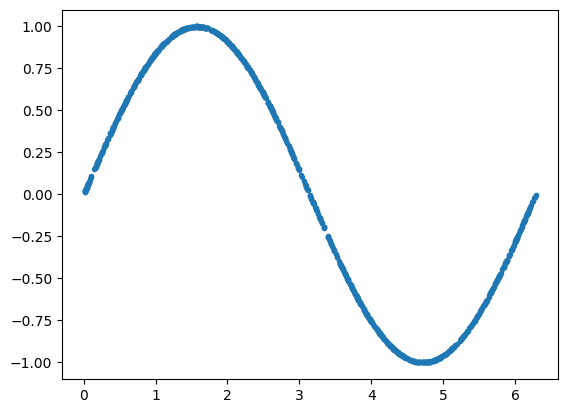

In [6]:
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.show()

In [7]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),  # activation function
            nn.Dropout(0.3),  # dropout to prevent overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # sigmoid activation to produce a probability
        )

    # Describe how the forward pass is calculated.
    def forward(self, x):
        output = self.model(x)
        return output

In [9]:
# After declaring the discriminator class, we instantiate a discriminator object.
discriminator = Discriminator()

In [10]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output


# Instantiate generator object.
generator = Generator()

In [11]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()

In [12]:
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

In [13]:
for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # Data for training the discriminator.
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        # Training the discriminator.
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator.
        latent_space_samples = torch.randn((batch_size, 2))

        # Training the generator.
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Print loss at various training stages.
        print_epoch_num = (
            100  # Change this depending on often the loss should be printed.
        )
        if epoch % print_epoch_num == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.10651857405900955
Epoch: 0 Loss G.: 2.6915292739868164
Epoch: 100 Loss D.: 0.6961967945098877
Epoch: 100 Loss G.: 0.7102952599525452
Epoch: 200 Loss D.: 0.6912709474563599
Epoch: 200 Loss G.: 0.6821829080581665
Epoch: 300 Loss D.: 0.6837543249130249
Epoch: 300 Loss G.: 0.6821314096450806
Epoch: 400 Loss D.: 0.644123911857605
Epoch: 400 Loss G.: 0.9219444394111633
Epoch: 500 Loss D.: 0.6838881969451904
Epoch: 500 Loss G.: 0.7201194763183594
Epoch: 600 Loss D.: 0.6421352624893188
Epoch: 600 Loss G.: 0.7165115475654602
Epoch: 700 Loss D.: 0.7381243109703064
Epoch: 700 Loss G.: 0.7110879421234131
Epoch: 800 Loss D.: 0.6873349547386169
Epoch: 800 Loss G.: 0.717972457408905
Epoch: 900 Loss D.: 0.6326367855072021
Epoch: 900 Loss G.: 0.6867722272872925
Epoch: 1000 Loss D.: 0.6920502185821533
Epoch: 1000 Loss G.: 0.810920774936676
Epoch: 1100 Loss D.: 0.6662740111351013
Epoch: 1100 Loss G.: 0.8285724520683289
Epoch: 1200 Loss D.: 0.6550095081329346
Epoch: 1200 Loss G.: 0.706

In [14]:
# Generate 1000 random 2D points and feed them to the generator.
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)

# Turn the PyTorch tensor into a NumPy array.
generated_samples_numpy = generated_samples.detach().numpy()

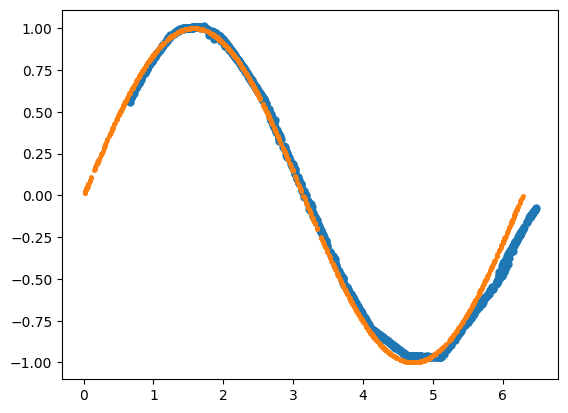

In [15]:
# Plot the generated samples and the original training data.
plt.plot(
    generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", markersize=10
)
plt.plot(train_data[:, 0], train_data[:, 1], ".", markersize=5)
plt.show()